Introduction: The dataset this project will be analyzing is a U.S. GDP Growth Rate report with data ranging from 2010 Q1 all the way to 2023 Q4. The dataset that was provided hails from the U.S. Bureau of Economic Analyis and includes 20 data points from the beginning of 2010 to the end of 2023 that have been adjusted to represent the seasonally adjusted rate (SARR) of real GDP growth in percentage. I will be applying 3 different methods of curve fitting and data analysis methods which include, cubic spline interpolation, polynomial comparison, and a least square regression comparison. Cubic spline interpolation is an interpolation method that constructs a smooth continuous curve through selected data points. Polynomial fitting is a process in which a certain degree of polynomial is used to assess data points and construct a line of best fit that will ignore noisy data (outlying data that may be represetative of an error or extreme case), and model non-linear data. Least square regression is a data analysis method that finds the line of best fit through a set of data points and creates a predictive model based off of y=m(x)+b, where m is the slope of the data and b is the intercept. I will be applying all three of these methods and then analyze their strengths and weaknesses in representing the GDP Growth Rate data points. 

In [13]:
#use CUSTOM least square regression, polynomial fitting, and cubic spline interpolation
#markdown cells for comments
#3 curve fittings and interpolation technicques
#Data Set
import numpy as np
import matplotlib.pyplot as plt

I begin my coding by implementing necessarily libraries. For this project, there are really only two libraries that need to be imported, numpy and matplotlib.pyplot. In importing numpy I must be careful as this project dictates that all my method applications must be custom and cannot use numpy functions. However, I can use numpy for linear algebra solutions as dictated by the rubric. Additionally, matplotlib.pyplot is necessary for all my graphing applications.

In [14]:
#Data Set
x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28,
29, 33, 37, 41, 42, 43, 45, 49, 54, 56])
y= [1.7,0.1,2.3,2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3]
print ("Time in Quarters starter at Q1 2010:", x)
print ("GDP Growth Percentage (%): ", y)

Time in Quarters starter at Q1 2010: [ 1  5  9 13 17 19 22 25 27 28 29 33 37 41 42 43 45 49 54 56]
GDP Growth Percentage (%):  [1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3]


This block outlines my data set. Since I have 20 data points starting at 2010 Q1, which is our first data point I can create a list from a range (1,21) where 1 is inclusive and representive of my first data point (2010 Q1) and 21 is non inclusive which makes the final value of the list, 20 representative of my final data point (2023 Q4). The y data set represents the respective GDP percentage of each of the quarters listed in the data set that was given to me by the U.S. Bureau of Economic Analysis. 

# Part A: CUBIC SPLINE INTERPOLENT

In [15]:
#Part A: Cubic Spline Interpolent
def adding_h (x):
    h=[]
    for i in range (len(x)-1):
        h_x = x[i+1]-x[i]
        h.append(h_x)
    return np.array(h)
h=adding_h(x)
print ("step size is equal to h vector: ", h)

#Thomas Algorithm:
import numpy as np
def thomas_algorithm(a, b, c, d):
    n = len(b)
# Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
# Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

#STEP 3 Set up and Solve Tridiagonal System
#Smoothness Condition
n= len(x)

a= np.zeros(n)
b= np.zeros(n)
c= np.zeros(n)
d= np.zeros(n)

#natural boundaries:
b[0]=1
d[0]=0

b[n-1]=1
d[n-1]=0

for i in range(1,n-1):
    a[i-1]= h[i-1]
    b[i]= 2*(h[i-1]+h[i])
    c[i]= h[i]
    d[i]= 6*(((y[i+1]-y[i])/h[i])-((y[i]-y[i-1])/h[i-1]))
    
M= thomas_algorithm(a.copy(),b.copy(),c.copy(),d.copy())
print("M:", M)

#Step 4 Eval Spline
def evaluate_spline(x, y, M, xeval):
    h = np.diff(x)
    
    # Step 1: find correct interval
    for i in range(len(x) - 1):
        if x[i] <= xeval <= x[i+1]:
            break
    
    # Step 2: compute spline using formula
    hi = h[i]
    
    term1 = M[i] * (x[i+1] - xeval)**3 / (6 * hi)
    term2 = M[i+1] * (xeval - x[i])**3 / (6 * hi)
    
    term3 = (y[i]/hi - M[i]*hi/6) * (x[i+1] - xeval)
    term4 = (y[i+1]/hi - M[i+1]*hi/6) * (xeval - x[i])
    
    return term1 + term2 + term3 + term4

step size is equal to h vector:  [4 4 4 4 2 3 3 2 1 1 4 4 4 1 1 2 4 5 2]
M: [ 0.00000000e+00  3.95919853e-01 -1.58679413e-01 -4.36202203e-01
  1.37848822e+00 -1.69852494e+00  1.09424311e-01  1.59416103e+00
 -3.63494160e+00  2.42132754e+00  1.14963145e+00 -2.27941050e+00
  7.74301054e+00 -3.19926317e+01  1.63254275e+02 -1.11624467e+02
  2.62962632e+01 -5.41405611e+00  1.78359147e+00  0.00000000e+00]


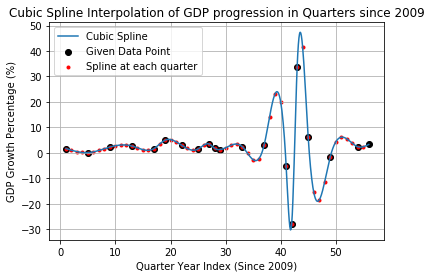

In [16]:
#Plotting the Cubic Spline interpolation
#PLOT
xsmooth = np.linspace(1, 56, 500)
ysmooth = [evaluate_spline(x, y, M, val) for val in xsmooth]
x_full = np.arange(1, 56)
y_full = [evaluate_spline(x, y, M, val) for val in x_full]
plt.scatter(x, y,marker='o',color='black', label='Given Data Point')
plt.scatter(x_full, y_full, marker='.', color='red', label='Spline at each quarter')
plt.plot(xsmooth, ysmooth, label='Cubic Spline')
plt.xlabel("Quarter Year Index (Since 2009)")
plt.ylabel("GDP Growth Percentage (%)")
plt.grid()
plt.legend()
plt.title("Cubic Spline Interpolation of GDP progression in Quarters since 2009")
plt.show()

Part A Explanation: This portion of code includes my custom implementation of Cubic Spline as well as the plot that was created from my data points, and split among the 55 quarters between the start and end of my data. The cubic spline interpolation is meant to create a fluid graph that will go through each of my data points and can then be interpolated to highlight the values of the quarters in between the data points that were previously given. In order to do this the cubic spline works by building a step size between each of the quarters (x values) and then running the thomas algorithm, which calculates the curve of the spline. The thomas algorithm solves the curvature of the line and outputs the equation that the line follows to create a curvature between all data points. I then evaluate the cubic spine using the evaluate spline function which will output 4 terms that correlate toe the cubic spline equation which dictates the motion of the graph through the data points. Following this I can plot the cubic spline graph to include all the quarter points. Additionally, I can evaluate the unknown points using the evaluate_spline function and plot those points on the graph as well. 

A1) Because the data we were given was n=20 points, there are 35 more unknown data points which are representative of unknown quarters between 2010 Q1 and 2023 Q1. The continuity equations are forced to be continuous by the tridiagonal system that is used to calculate the cubic spline. There are 3 continuity equations that must be defined, the function continuity condition, first derivative condition, and second derivative condition with boundary conditions also acting as the fourth condition. The function continuity (interpolation continuation) must go through each point, essentially meaning that at every knot between the points, in which there is 19 knot segments, the data point on the left and right side of the data must match. The next condition that must be met is the first derivative condition test, which is classified by n-2=18 equations due to the interior slopes, which equates to 18 unknown values for the first derivative continutity. In order to ensure continuity here the slope on each side of the knot must be equal to withstand it. The second derivative test also runs on n-2 equations in order to ensure continuity in curvature, this is ensured by making sure the curvature on each side of the knot is equal. The boundary conditions must be ensured by the endpoints and setting the curvature outside of the endpoints to zero in order to ensure a smooth graph that ends. We must set the curvature to 0 at the outer knots. All of the continuity equations are supported, and ensured by the thomas algorithm. This is exemplified in the actual graph, which is continuous through all data points

A2) The interpolent is smooth and easy to follow as it accurately demonstrates each of the quarters on the x-axis. Additionally, it accurately demonstrates the delivered data point as well as the spline interpolated points at the unknown quarters. These interpolated points are reinforced by boundary conditions that are establisehed in the thomas algorithm. The graph is smooth through a division of 500 points which allows for a smooth demonstration of the cubic spline. 

A3) The Runge Phenomenon is an issue that arises when interpolating high degree polynomials. It especially arises when the space between data points approaches unifomity. The Runge Phenomenon occurs when there is extremes in data and you are trying to establish a high degree polynomial fit. The cubic spline was developed to try to avoid this Runge Phenomenon as everything runs on 3rd degree polynomials. However, as the graph builds the cubic spline, which must iterate through each data point, the curve develops large oscillations in order to clealy go through the next data point. These oscillations show wild swings and poor interpolation approximations. There is a tradeoff between exact interpolation and numerical stability. Exact interpolation treats all points as truth and not as noise, which could lead to wild oscillations. Trading it for numberical stability shows a smoother graph with less oscillations, however, it may fail to pass through each point and may not pass through some points excluding them from the spline. Smoothing splines would help mitigate the issue of wild oscillations, they would dip down and rise during the outliers, but they wouldn't rise and fall far enough to cause wild oscillations. Weighted Least Square assigns weighted values to outliers, and weighs them as less significant when constructing the line of best fit. For this application I would opt to go toward Weighted Least Square method because it better ignores the outliers, and with my goal being a model of the general GDP trend, I would prefer to go with the method that better ignores outliers.

# Part B1: Polynomial Fitting

In [17]:
#Part B1: Polynomial Fitting
degree=4

x_mean = np.mean(x)
x_std = np.std(x)
x_scaled = (x - x_mean) / x_std

#vandermonde matrix 
def create_vandermonde(x, degree):
    return np.vander(x, N=degree+1, increasing=True)

V = create_vandermonde(x_scaled, degree)
VT_V = np.dot(V.T, V)
cond_num = np.linalg.cond(VT_V)
print ("Condition Number of VT_V: ", cond_num)
if (cond_num < 1e12):
    print("Condition number valid, its below the threshold (1*10^12)")

# coefficients
def vandermonde_fit(x_scaled, y, degree):
    V = create_vandermonde(x_scaled, degree)
    VT_V = np.dot(V.T, V)
    VT_y = np.dot(V.T, y)
    coefficients = np.linalg.solve(VT_V, VT_y)
    return coefficients

# y values
def predict(x_scaled, coefficients):
    degree = len(coefficients) - 1
    V = create_vandermonde(x_scaled, degree)
    return np.dot(V, coefficients)

# Evaluate model
def evaluate(y, y_pred):
    mse = np.mean((y - y_pred)**2)
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_pred)**2)
    r2 = 1 - (ss_res / ss_total)
    return mse, r2

#printing all the vandermonde values
print("Vandermonde Polynomial Fit Results:")
coeffs = vandermonde_fit(x_scaled, y, degree)
y_pred = predict(x_scaled, coeffs)
mse, r2 = evaluate(y, y_pred)
print("Degree:", degree)
print("Coefficients:", coeffs)

print("\nEVALUATION INFORMATION:")
print("MSE:", mse)
print("R^2:", r2)

#Standard Error of the Estimate:
n= np.size(x)
m= degree+1
SSres= np.sum((y-y_pred)**2)
Sy= np.sqrt(SSres/(n-m))
print ("Standard Error of Estimate:", Sy)

#Residuals
residuals= y-y_pred

Condition Number of VT_V:  264.97153725050106
Condition number valid, its below the threshold (1*10^12)
Vandermonde Polynomial Fit Results:
Degree: 4
Coefficients: [ 1.89567689 -1.1420332   0.43135087  0.5950551  -0.10342407]

EVALUATION INFORMATION:
MSE: 100.62980208981801
R^2: 0.0035410151185394367
Standard Error of Estimate: 11.58330995238799


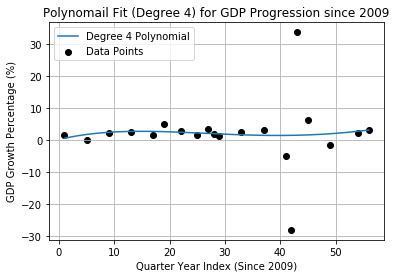

In [18]:
#Plotting Polynomial
x_smooth = np.linspace(min(x), max(x), 200)
x_smooth_scaled=(x_smooth-x_mean)/x_std
y_smooth = predict(x_smooth_scaled, coeffs)
plt.scatter(x, y, marker='o', color='black', label='Data Points')
plt.plot(x_smooth, y_smooth, label=f"Degree {degree} Polynomial")
plt.xlabel("Quarter Year Index (Since 2009)")
plt.ylabel("GDP Growth Percentage (%)")
plt.title("Polynomail Fit (Degree 4) for GDP Progression since 2009")
plt.legend()
plt.grid()
plt.show()

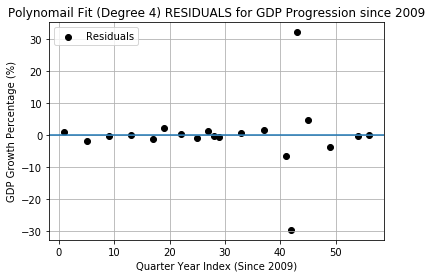

In [19]:
#Plotting Residual Plots
plt.figure()
plt.scatter(x, residuals,color= 'black', label='Residuals')
plt.axhline(0)  # important reference line
plt.xlabel("Quarter Year Index (Since 2009)")
plt.ylabel("GDP Growth Percentage (%)")
plt.title("Polynomail Fit (Degree 4) RESIDUALS for GDP Progression since 2009")
plt.legend()
plt.grid()
plt.show()

[]

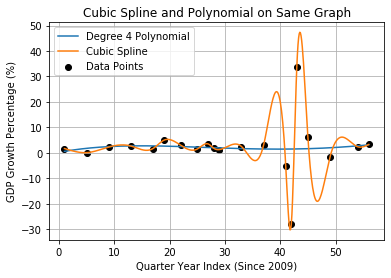

In [20]:
#Cubic Spline and Polynomial on Same Graph
plt.title("Cubic Spline and Polynomial on Same Graph")
plt.xlabel("Quarter Year Index (Since 2009)")
plt.ylabel("GDP Growth Percentage (%)")
plt.scatter(x, y, marker='o', color='black', label='Data Points')
plt.plot(x_smooth, y_smooth, label=f"Degree {degree} Polynomial")
xsmooth = np.linspace(1, 56, 500)
ysmooth = [evaluate_spline(x, y, M, val) for val in xsmooth]
plt.plot(xsmooth, ysmooth, label='Cubic Spline')
plt.grid()
plt.legend()
plt.plot()

Part B Polynomial Explanation: The cells above details my custom function of polynomial fitting. Since the assignment dictates that the respective degree for the polynomial fitting is degree 4 I can assign the degree to that value at the beginning of the function. I also centered and scaled the x value to make the condition number valid under the tolerance. The polynomial function works by finding a smooth curve that minimizes the distance from it to all my observed data simulatenously. The Vandermonde matrix is the component that takes my data and transforms it into specific values that are then implemented into the polynomial equation that outlines the line of best fit according to the degree of the polynomial. With the degree being 4, the Vandermonde builds a 20 by 5, since I have 20 data points and 5 coefficients, with the highest being x^4. Following this I ran MSE, R^2, and Standard Error Estimate analysis. The Mean Squared Error, is the average of the squares of the errors, since our value was approximately 100.62 our graph fails to be accurate according to data, as the smaller the MSE the more applicable the polynomial is to our data. The coefficient of determination or R^2 indicates how much of the varience is explained by the model. Since our R^2 is extremely low at 0.0035 our graph fails to explain much of the varience in the graph, and is not a good model. This also hints to the idea that time isn't the sole reason behind the varience of the graph, which is accurate considering the outliers cause by COVID. Standard Error Analysis measures the typical distance from the data to the polynomial line. The standard error estimate of around 11 is reflectionate of a wide varience in data location and line location, this is likely due to the oscillations and distance created during the COVID years. 

B1: The Cubic Spline better represents specific data points, as it goes through each data point, making it a useful tool to seeing the rise and fall between difference data points, especially the outliers caused by COVID. The Polynomial function is better used for approximation, as it doesn't follow all the data points, and doesn't go through each point, which allows it to better follow the trend of the data. In avoiding the oscillations caused by the COVID data, the polynomial line is a better representation of the overall trend of GDP growth percentage. The tradeoff between interpolation and approximation occurs here, the more interpolated a data set it, the more likely the graph will suffer from oscillations and fail to follow a general trend, as it is swayed by outliers. However, approximations such as the polynomial method are better for following a general trend, yet they will not encompass all data, and may not pass through each point. The accuracy in interpolation comes at the risk of losing accuracy in general trends and following outliers, while the tradeoff for generalization may be that the curve doesn't intersect each point. 

# Part B2: Least Square Linear Model

In [21]:
#Part B2: Least Square
x = np.array(x)
y = np.array(y)
#Mask Data, nothing from the COVID years 2020 q1 to 2021 q1
covid_start = 41
covid_end = 45

mask = (x<covid_start) | (x>covid_end)
x_filtered = x[mask]
y_filtered = y[mask]

#Coded least square heart of lslm
def coded_least_square(x_filtered,y_filtered):
    n=len(x_filtered)
    sum_x= np.sum(x_filtered)
    sum_y= np.sum(y_filtered)
    sum_x2=np.sum(x_filtered**2)
    sum_xy=np.sum(x_filtered*y_filtered)
    
    m=(n*sum_xy-sum_x*sum_y)/(n*sum_x2-(sum_x)**2)
    c=(sum_y-m*sum_x)/n
    return m,c

#Slope and constant calculation
m_data,c_data=coded_least_square(x_filtered,y_filtered)
print("Coded Least Square with Data")
print(f"Data Linear Fit: y= {m_data:.6f}x+{c_data:.6f}")
print("Calculated Slope: ", m_data)
print("Calculated Intercept: ", c_data, "\n")
y_data=m_data*x_filtered+c_data

#Evaluate Model
def evaluate(y_data, y_filtered):
    mseL = np.mean((y_filtered - y_data)**2)
    ss_total_lin = np.sum((y_filtered - np.mean(y_filtered))**2)
    ss_res_lin = np.sum((y_filtered - y_data)**2)
    R2L = 1 - (ss_res_lin / ss_total_lin)
    return mseL, R2L
#outtputting the evaluations
mseL,R2L= evaluate(y_data, y_filtered)
print ("LEAST SQUARE EVALUATION INFORMATION:")    
print("MSE: ", mseL)
print("R^2: ", R2L)

#Residuals for linear stuff
residual_lin= y_filtered-y_data

Coded Least Square with Data
Data Linear Fit: y= -0.001907x+2.194285
Calculated Slope:  -0.001906988188976378
Calculated Intercept:  2.194285187007874 

LEAST SQUARE EVALUATION INFORMATION:
MSE:  2.0827872400959646
R^2:  0.00044329440682566723


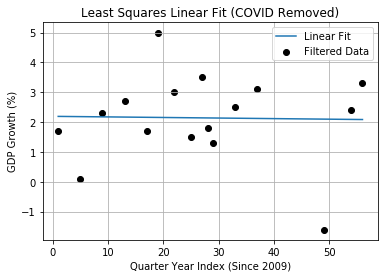

In [22]:
#Plotting 
x_smooth = np.linspace(min(x_filtered), max(x_filtered), 200)
y_line = m_data*x_smooth + c_data
plt.scatter(x_filtered, y_filtered, color='black', label='Filtered Data')
plt.plot(x_smooth, y_line, label='Linear Fit')
plt.xlabel("Quarter Year Index (Since 2009)")
plt.ylabel("GDP Growth (%)")
plt.title("Least Squares Linear Fit (COVID Removed)")
plt.grid()
plt.legend()
plt.show()

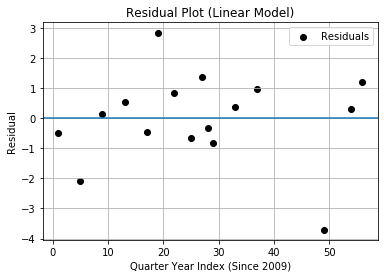

In [23]:
#LST SQUARE RESIDUALS
plt.figure()
plt.scatter(x_filtered, residual_lin, color='black', label='Residuals')
plt.axhline(0)
plt.xlabel("Quarter Year Index (Since 2009)")
plt.ylabel("Residual")
plt.title("Residual Plot (Linear Model)")
plt.legend()
plt.grid()
plt.show()

Part B2 Least Square Linear Regression: The least square linear regression works by removing COVID outliers from the data set before any model is constructed. Following this the Least Square Linear Regression interpretation calculates a slope and intercept that will build an equation to evaluate the y-value dependent on the x value. The coded_least_square function is the lifeblood of this equation, and calculates the slope and intercept for the linear equation. Following this the equation is evaluated for the MSE and R^2 values. Here I found that the MSE was around a 2.08 meaning that the mean squared error was pretty accurate between the predicted linear model and the observed data. Additionally, the R^2 of 0.00044 details that there is little relationship between the data and a linear model. This tends to be pretty accurate as GDP growth does not tend to be a linear model due to business cycles.

B2: Linear relationships are almost never represetnative of GDP data. The low R^2 applies to this theory as it shows that very little of the data is represented by the linear relationship. While the removal of outliers helps decrease the MSE in this sense, it still doesn't reflect the data properly, as shown by the residual plot being all over the place. For a linear model to fit GDP and economic growth, the assumption that the economy is constantly growing or declining. It also makes the assumption that business cycles don't occur, and there are no global events or economic trends that could derail the economy. Essentially, for a linear fit to correlate to ecnomic growth, the assumption must be made that the economy will be constant. 

# Part C Method Justification

#Part C- For a policymaker who needs to estimate GDP growth for a quarter between two known
data points (interpolation), which method would you recommend: cubic spline or polynomial
fitting? Justify your answer with reference to smoothness, accuracy, and sensitivity to
outliers.

For a policymaker needing to estimate GDP growth for a quarter between two known data points, I would recommend using cubic spline interpolation. First, polynomial fitting is good for modelling general trends, which can be exemplified by my previous graph. The polynomial fit can model the general trend of the economic data, however, in providing a good general model, it fails to go through each data point, and proved to leave out data points. This isn't necessarily all bad, as polynomial functions are better suited for ignoring outliers, which can be demonstrated as the polynomial function ignored the COVID outliers by not oscillating to their level. However, the polynomial graph didn't go through the majority of data points and as a result ignored some of the points mistaking them for "noise". Additionally, the inaccuracy of the polynomial model is demonstrated in the MSE discrepancy with the polynomial model clocking in around 100 mean squared error. Additionally the coefficient of determination for the polynomial model was 0.0035 showing that hardly any of the data could be explained by the model, and that it was highly inaccurate. However, where the polynomial model fails to be accurate, the cubic spline model shines.

The Cubic Spline model is my method of choice because of it's high accuracy in encapsulating all points. The cubic spline is built to go through each data point, and because of continuity boundaries enforced in the thomas algorithm, which force each knot to equate to its subsequent segment on the left and right, as well as the slope of each segment equating at the knots, and its respective curvature equating at the knots, the cubic spline builds a clean model through each data point. However, this high level of accuracy creates an oscillation between data points, especially between outliers. The cubic spline does not account for outliers and will create oscillations between uniform x-value data points. Additionally, the outliers contribute to the Runge Phenomenon in which cubic spline models and high degree polynomial models will wiggle toward their boundaries. However, the MSE and the R^2 are 0 and 1 respectively, meaning they perfectly represent the data set. Because of this, they can be good for interpolation, which would be perfect for our applications.

Ultimately, the cubic spline model is the better way to estimate GDP growth for a quarter between two known data points because of it's accuracy in representing known data, and it's smoothness guarenteed by boundary conditions despite being more sensitive to outliers. 

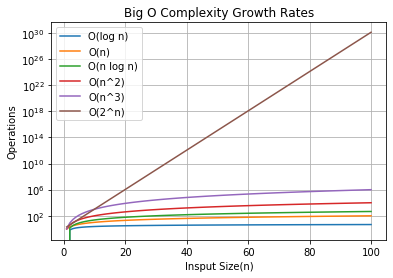

In [24]:
# BIG O THEORETICAL GROWTH PLOT, shout out TA
n =np.linspace(1,100,100)
plt.plot(n,np.log(n),label='O(log n)')
plt.plot(n,n,label='O(n)')
plt.plot(n,n*np.log(n),label='O(n log n)')
plt.plot(n, n**2, label= 'O(n^2)')
plt.plot(n,n**3, label= 'O(n^3)')
plt.plot(n,2**n, label= 'O(2^n)')
plt.yscale('log')
#logarithmic scale for visuality
plt.title('Big O Complexity Growth Rates')
plt.xlabel('Insput Size(n)')
plt.ylabel('Operations')
plt.legend()
plt.grid()
plt.show()

Big O is used to determine the effenciency of an algorithm. Essentially, it measures how the number of operations would grow as the input size grows, showing how more complex solutions would take more operations and take "longer" to solve. Least Square Linear model is simple and only requires basic computations such as multiplication and addition, meaning that it runs quickly based off of O(n). The polynomial interpretation takes the longest because it is the most complex due to the Vandermonde Matrix linear algebra solving, which takes a lot of operations and takes the longest out of the three methods. The Cubic Spline, through the tridiagonal system is actually incredibly fast and runs on the same O(n) as least square linear because it only requires simple multiplication and addition functions, and calculates all coefficients at the same time. Because of the lack of difference in speed to solve between the linear and cubic spline, the cubic spline still reigns supreme and would be my choice of interpretation. 

# Conclusion

The cubic spline interpolation is the best for interpolation between known data points, however it suffers in it's aspect that it's sensitive to outliers and can fall victim to oscillations and the Runge Phenomenon. The polynomial fitting probably worked best for trend analysis as it's resistant to outliers and isn't swayed as much, allowing it to capture a nice general trend of the data. However, the polynomial function failed to be accurate in showing precise data points and failed to hit much of the values in the data. The Least Square Linear fit oversimplifies the trends of economic cycles, and while taking out the COVID years, it made it a more accurate model, it still fails to explain the data according to a least square model. However, if the data were more predictable and steady, a least square model would be good for showing a general trend. 